# ndvi_smol

### Here we gather Sentinel-2 data to calculate plot ndvi 

In [1]:
# # For Sentinel-2
# # !pip install sentinelsat
# import sys
# !{sys.executable} -m pip install sentinelsat

In [2]:
import numpy as np
import ee
import geemap
import geopandas as gpd
from tqdm import tqdm
import pandas as pd
import os
# os.chdir('..')
import matplotlib.pyplot as plt
import numpy as np
from scipy import integrate
from scipy.stats import zscore
from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings
import os

pd.set_option('display.max_columns', None)

In [3]:
downloaded = False

ndvi_files = [
    'ndvi_2016-01-01_to_2016-12-31.csv',
    'ndvi_2017-01-01_to_2017-12-31.csv',
    'ndvi_2018-01-01_to_2018-12-31.csv',
    'ndvi_2019-01-01_to_2019-12-31.csv',
    'ndvi_2020-01-01_to_2020-12-31.csv',
    'ndvi_2021-01-01_to_2021-12-31.csv',
    'ndvi_2022-01-01_to_2022-12-31.csv',
    'ndvi_2023-01-01_to_2023-12-31.csv',
    'ndvi_2024-01-01_to_2024-12-31.csv',
    'ndvi_2025-01-01_to_2025-12-31.csv',
]

data_dir = '../data/ndvi/plots/'

ndvi_file_paths = [os.path.join(data_dir, ndvi_file) for ndvi_file in ndvi_files]

if all(os.path.isfile(path) for path in ndvi_file_paths):
    downloaded = True

In [4]:
def add_indices(image):
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('ndvi')
    evi = image.expression(
        '2.5 * ((NIR - RED) / (NIR + 6*RED - 7.5*BLUE + 1))',
        {'NIR': image.select('B8'), 'RED': image.select('B4'), 'BLUE': image.select('B2')}
    ).rename('evi')
    ndwi = image.normalizedDifference(['B8', 'B11']).rename('ndwi')
    savi = image.expression(
        '((NIR - RED) / (NIR + RED + 0.5)) * 1.5',
        {'NIR': image.select('B8'), 'RED': image.select('B4')}
    ).rename('savi')
    rendvi = image.normalizedDifference(['B8', 'B5']).rename('rendvi')
    mcari2 = image.expression(
        '((NIR - RE) - 0.2*(NIR - RED)) * (NIR / RE)',
        {'NIR': image.select('B8'), 'RED': image.select('B4'), 'RE': image.select('B5')}
    ).rename('mcari2')
    
    return image.addBands([ndvi, evi, ndwi, savi, rendvi, mcari2])



def mask_clouds(img, cloud_prob_threshold=20):
    '''Mask clouds using s2cloudless probability band.'''
    cloud_prob = ee.ImageCollection('COPERNICUS/S2_CLOUD_PROBABILITY') \
        .filter(ee.Filter.eq('system:index', img.get('system:index'))).first()
    clouds = cloud_prob.gt(cloud_prob_threshold)
    mask = clouds.Not()
    return img.updateMask(mask)


def reduce_region(img, geom, plot_id):
    # all EE operations
    stats = img.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=geom,
        scale=10,
        bestEffort=True,
        maxPixels=1e13
    )
    props = {k: stats.get(k) for k in [
        'ndvi',#'evi','ndwi','savi','rendvi','mcari2'
    ]}
    props['date'] = img.date().format('YYYY-MM-dd')
    props['plot_id'] = plot_id
    return ee.Feature(None, props)



## Here we initialize our access to the satellite data download. 
## Requires authentication via browser.

In [5]:
if downloaded == False:
    
    
    ee.Authenticate()
    ee.Initialize(project="ee-simonhansedasi")

    # load the vineyard polygon (GeoJSON)
    vineyard = pd.read_pickle('../data/polygons/RegressionRidge_smol_smol.pkl')


    from shapely.geometry import Polygon, MultiPolygon

    # your existing GeoDataFrame
    gdf = vineyard.copy()

    rows = []
    for idx, row in gdf.iterrows():
        geom = row.geometry
        parent = row['plot_id']

        if isinstance(geom, Polygon):
            rows.append({"geometry": geom, "parent_plot": parent})
        elif isinstance(geom, MultiPolygon):
            for poly in geom.geoms:
                rows.append({"geometry": poly, "parent_plot": parent})

    # create new flattened GeoDataFrame
    vineyard_flat = gpd.GeoDataFrame(rows, crs=gdf.crs)



    geoms = [ee.Geometry.Polygon(list(p.exterior.coords)) for p in vineyard_flat.geometry]
    
    
if downloaded == True:
    print('data already downloaded')


### The below code will loop over a given set of years starting in 2016 (earliest available data), search for the polygon coordinates and compute ndvi for our plots. Finally, the data is serialized as a pandas pickle file.

Set dates to search over. Make sure there is a 'plots' folder for the plot ndvi data

In [6]:
if downloaded == False:
    years = [str(year) for year in range(2016, 2026)]
    months = ['01', '12']
    days = ['01', '31']
    start_dates = [f'{year}-{months[0]}-{days[0]}' for year in years]
    end_dates   = [f'{year}-{months[1]}-{days[1]}' for year in years]

    os.makedirs('data/ndvi/plots', exist_ok=True)
    
    
if downloaded == True:
    print('already been here')

Loop over years and search database for images overlapping our polygons. Then download the and st

In [7]:
if downloaded == False:

    # --- Flatten MultiPolygons if necessary ---
    def shapely_to_ee_feature(poly, plot_id):
        """Convert a Polygon or MultiPolygon to EE Feature with plot_id property."""
        if poly.geom_type == 'Polygon':
            return ee.Feature(ee.Geometry.Polygon(list(poly.exterior.coords)), {'plot_id': plot_id})
        elif poly.geom_type == 'MultiPolygon':
            features = []
            for p in poly.geoms:
                features.append(ee.Feature(ee.Geometry.Polygon(list(p.exterior.coords)), {'plot_id': plot_id}))
            return ee.FeatureCollection(features)
        else:
            raise ValueError(f"Unsupported geometry type: {poly.geom_type}")
            
            
if downloaded == True:
    print('polygons already flattened')

In [8]:
if downloaded == False:
    # Flatten GeoDataFrame into FeatureCollection
    ee_features = []
    for idx, row in tqdm(vineyard_flat.iterrows()):
        poly = row.geometry
        parent = row.get('parent_plot', f'plot_{idx}')
        feat = shapely_to_ee_feature(poly, parent)

        if isinstance(feat, ee.FeatureCollection):
            ee_features.extend(feat.toList(feat.size()).getInfo())
        else:
            ee_features.append(feat.getInfo())

    # hex_fc['geometry'] = hex_fc.geometry.buffer(5)  # buffer by 5 meters

    hex_fc = ee.FeatureCollection(ee_features)
    
if downloaded == True:
    print('already done')

3598it [05:56, 10.08it/s]


In [9]:
if downloaded == False:
    for start_date, end_date in zip(start_dates, end_dates):
        # Only export years not already downloaded
        year = start_date[:4]
        fname = f'../data/ndvi/plots/ndvi_{start_date}_to_{end_date}.csv'
        if os.path.isfile(fname):
            print(f'{year} already downloaded, skipping')
            continue

        # Load Sentinel-2 collection and add indices
        collection = (
            ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
            .filterBounds(hex_fc)
            .filterDate(start_date, end_date)
            .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
            .select(['B2', 'B4', 'B5', 'B8', 'B11'])
            .map(add_indices)
        )

        # Server-side extraction: map reduce_region over each hex for each image
        def extract_features(img):
            return hex_fc.map(
                lambda f: reduce_region(
                    img,
                    f.geometry(),
                    f.get('plot_id')
                )
            )

        # Flatten all features across all images
        fc = collection.map(extract_features).flatten()

        # Export to Google Drive as CSV to avoid memory issues
        task = ee.batch.Export.table.toDrive(
            collection=fc,
            description=f'ndvi_{start_date}_to_{end_date}',
            folder=f'ee_ndvi_exports_{start_date}_to_{end_date}',
            fileFormat='CSV'
        )
        task.start()
        print(f"Export started for {start_date} to {end_date}. Check Google Drive folder 'ee_ndvi_exports_{start_date}_to_{end_date}'.")

if downloaded == True:
    print('data already exported')

Export started for 2016-01-01 to 2016-12-31. Check Google Drive folder 'ee_ndvi_exports_2016-01-01_to_2016-12-31'.
Export started for 2017-01-01 to 2017-12-31. Check Google Drive folder 'ee_ndvi_exports_2017-01-01_to_2017-12-31'.
Export started for 2018-01-01 to 2018-12-31. Check Google Drive folder 'ee_ndvi_exports_2018-01-01_to_2018-12-31'.
Export started for 2019-01-01 to 2019-12-31. Check Google Drive folder 'ee_ndvi_exports_2019-01-01_to_2019-12-31'.
Export started for 2020-01-01 to 2020-12-31. Check Google Drive folder 'ee_ndvi_exports_2020-01-01_to_2020-12-31'.
Export started for 2021-01-01 to 2021-12-31. Check Google Drive folder 'ee_ndvi_exports_2021-01-01_to_2021-12-31'.
Export started for 2022-01-01 to 2022-12-31. Check Google Drive folder 'ee_ndvi_exports_2022-01-01_to_2022-12-31'.
Export started for 2023-01-01 to 2023-12-31. Check Google Drive folder 'ee_ndvi_exports_2023-01-01_to_2023-12-31'.
Export started for 2024-01-01 to 2024-12-31. Check Google Drive folder 'ee_ndvi_

In [10]:
# import ee
# ee.Initialize(project='ee-simonhansedasi')

# tasks = ee.batch.Task.list()

# for t in tasks:

#     print(f"ID: {t.id}")
#     print(f"Type: {t.task_type}")
#     print(f"Description: {t.config.get('description')}")
#     print(f"State: {t.state}")
#     print()


# We have manually downloaded .CSV files from google drive. Now we will manually put them together.

In [14]:

dfs = []
data_path = '../data/ndvi/plots/'

for file_path in tqdm(ndvi_files):

    ndvi_path = os.path.join(data_path, file_path)
    df = pd.read_csv(ndvi_path)
    df = df[['date','ndvi', 'plot_id']]
    
    dfs.append(df)
    
df = pd.concat(dfs, axis = 0)
df = df.reset_index(drop = True)

100%|███████████████████████████████████████████| 10/10 [00:01<00:00,  7.42it/s]


In [15]:
hampel_filter_pth = '../data/ndvi/plots/hampel_filtered.pkl'

if not os.path.isfile(hampel_filter_pth):
    def hampel_filter_series(s, window=7, n_sigmas=3):
        """
        Hampel filter for 1D pandas Series.

        Parameters:
        - s: pd.Series, time-ordered
        - window: half-window size (total window = 2*window+1)
        - n_sigmas: threshold multiplier

        Returns:
        - pd.Series with outliers replaced by NaN
        """
        k = 1.4826  # scale factor for MAD
        s_clean = s.copy()

        # rolling median and MAD
        rolling_med = s.rolling(window=2*window+1, center=True, min_periods=1).median()
        rolling_mad = s.rolling(window=2*window+1, center=True, min_periods=1).apply(
            lambda x: np.median(np.abs(x - np.median(x))), raw=True
        )

        # avoid zero MAD
        rolling_mad[rolling_mad == 0] = 1e-6

        # compute deviations
        diff = np.abs(s - rolling_med)
        threshold = n_sigmas * k * rolling_mad

        # replace outliers with NaN
        s_clean[diff > threshold] = np.nan
        return s_clean

    # list of columns to filter
    cols_to_filter = [
        'ndvi', #'evi', 'ndwi', 'savi', 'rendvi', 'mcari2'
    ]

    for col in tqdm(cols_to_filter):
        # apply Hampel filter group-wise
        df[col] = df.groupby('plot_id')[col].transform(
            lambda s: hampel_filter_series(s, window=7, n_sigmas=2)
        )

        # smooth filtered series
        df[f'{col}_smooth'] = df.groupby('plot_id')[col].transform(
            lambda s: s.rolling(window=7, center=True, min_periods=1).mean()
        )
    df.to_pickle(hampel_filter_pth)
    print("Hampel filter and smoothing done!")
if os.path.isfile(hampel_filter_pth):
    print('file is here')
    df = pd.read_pickle(hampel_filter_pth)

    
df

100%|█████████████████████████████████████████████| 1/1 [00:50<00:00, 50.87s/it]

Hampel filter and smoothing done!
file is here


,date,ndvi,plot_id,ndvi_smooth
0,2016-02-08,NaN,0,0.413494
1,2016-02-08,0.230203,1,0.287002
2,2016-02-08,0.207959,2,0.250898
3,2016-02-08,0.235524,3,0.242686
4,2016-02-08,NaN,4,0.410375
...,...,...,...,...
1781005,2025-12-29,NaN,3593,0.411444
1781006,2025-12-29,NaN,3594,0.382371
1781007,2025-12-29,NaN,3595,0.373429
1781008,2025-12-29,NaN,3596,0.406706


### Let's do a quick stats check here. Figure out how confident we are in these smoothed curves

In [16]:
df.isna().sum()

date                0
ndvi           115639
plot_id             0
ndvi_smooth        80
dtype: int64

In [17]:
# Identify your index columns
id_cols = ["plot_id", "date"]

# Raw indices
raw_cols = [
    "ndvi",#"evi","ndwi","savi","rendvi","mcari2"
]

# Smooth versions
smooth_cols = ['ndvi_smooth']#[c+"_smooth" for c in raw_cols]

# Step 1: Fill raw with smoothed, then median per plot, then global median
for raw, smooth in zip(raw_cols, smooth_cols):
    
    df[raw] = df[raw].fillna(df[smooth])  # use smoothed
    df[raw] = df.groupby("plot_id")[raw].transform(lambda x: x.fillna(x.median()))
    df[raw] = df[raw].fillna(df[raw].median())

# Step 2: Fill smooth (only a few NaNs)
for col in smooth_cols:
    df[col] = df.groupby("plot_id")[col].transform(lambda x: x.fillna(x.median()))
    df[col] = df[col].fillna(df[col].median())

# Step 3: Recompute residuals
for raw, smooth in zip(raw_cols, smooth_cols):
    resid = raw + "_residual"
    resid_pct = raw + "_residual_pct"
    df[resid] = df[raw] - df[smooth]
    # To avoid divide-by-zero, use np.where
    df[resid_pct] = np.where(df[smooth] != 0, df[resid] / df[smooth], np.nan)


In [18]:
df['date'] = pd.to_datetime(df['date'])

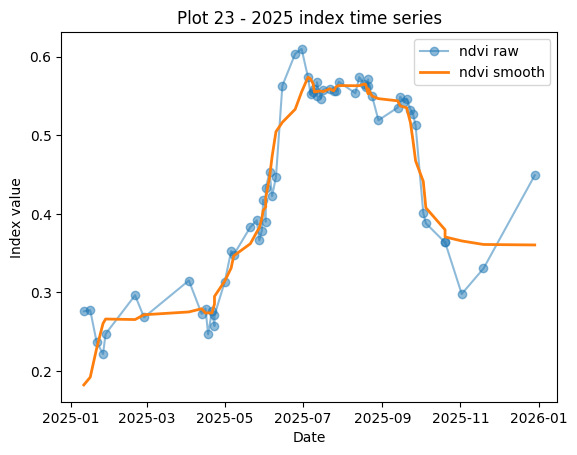

In [19]:
plot_id = 23    # example plot
year = 2025    # example year

df_plot = df[(df['plot_id']==plot_id) & (df['date'].dt.year==year)].sort_values('date')

indices = [
    'ndvi',#'evi','ndwi','savi','rendvi','mcari2'
]

# plt.figure(figsize=(14,6))
for idx in indices:
    plt.plot(df_plot['date'], df_plot[idx], 'o-', alpha=0.5, label=f'{idx} raw')
    sm = idx + '_smooth'
    if sm in df_plot.columns:
        plt.plot(df_plot['date'], df_plot[sm], '-', lw=2, label=f'{idx} smooth')
    plt.title(f'Plot {plot_id} - {year} index time series')
    plt.xlabel('Date')
    plt.ylabel('Index value')
    plt.legend()
    plt.show()


In [20]:
veg_features = [
    'ndvi_smooth',
                # 'evi_smooth', 'ndwi_smooth', 'savi_smooth', 'rendvi_smooth', 'mcari2_smooth'
]

df['month'] = df['date'].dt.month
df['week'] = df['date'].dt.week

/home/simonhans/anaconda3/envs/GrapeExpectations/lib/python3.7/site-packages/ipykernel_launcher.py:7: FutureWarning: Series.dt.weekofyear and Series.dt.week have been deprecated.  Please use Series.dt.isocalendar().week instead.
  import sys


In [21]:
df

,date,ndvi,plot_id,ndvi_smooth,ndvi_residual,ndvi_residual_pct,month,week
0,2016-02-08,0.413494,0,0.413494,0.000000,0.000000,2,6
1,2016-02-08,0.230203,1,0.287002,-0.056799,-0.197904,2,6
2,2016-02-08,0.207959,2,0.250898,-0.042939,-0.171140,2,6
3,2016-02-08,0.235524,3,0.242686,-0.007162,-0.029513,2,6
4,2016-02-08,0.410375,4,0.410375,0.000000,0.000000,2,6
...,...,...,...,...,...,...,...,...
1781005,2025-12-29,0.411444,3593,0.411444,0.000000,0.000000,12,1
1781006,2025-12-29,0.382371,3594,0.382371,0.000000,0.000000,12,1
1781007,2025-12-29,0.373429,3595,0.373429,0.000000,0.000000,12,1
1781008,2025-12-29,0.406706,3596,0.406706,0.000000,0.000000,12,1


In [22]:
df_orig = df.copy()

In [23]:
df = df_orig.copy()

In [24]:
stretched_pth = '../data/ndvi/plots/ndvi_stretch_daily.pkl'
if not os.path.isfile(stretched_pth):
    print('stretching df')
    def stretch_to_daily_per_year(g):
        # g is all data for one plot_id
        daily_parts = []
        for year, g_year in (g.groupby(g['date'].dt.year)):
            g_year = g_year.copy()
            numeric_cols = g_year.select_dtypes(include=[np.number]).columns.tolist()
            if 'date' in numeric_cols:
                numeric_cols.remove('date')

            # Collapse duplicate dates
            g_year = (g_year.groupby('date')
                      .agg({**{c: 'mean' for c in numeric_cols},
                            **{c: 'first' for c in g_year.columns.difference(numeric_cols + ['date'])}})
                      .reset_index()
                     )

            g_year = g_year.set_index('date').sort_index()
            full_idx = pd.date_range(start=g_year.index.min(), end=g_year.index.max(), freq='D')
            g_year = g_year.reindex(full_idx)

            g_year['plot_id'] = g_year['plot_id'].ffill().bfill()
            for col in numeric_cols:
                g_year[col] = g_year[col].interpolate(method='time', limit_direction='both')

            non_numeric = [c for c in g_year.columns if c not in numeric_cols + ['plot_id']]
            if non_numeric:
                g_year[non_numeric] = g_year[non_numeric].ffill().bfill()

            g_year = g_year.reset_index().rename(columns={'index':'date'})
            daily_parts.append(g_year)

        return pd.concat(daily_parts, axis=0)


    full_daily = df.groupby(
        'plot_id', as_index=False
    ).apply(lambda g: stretch_to_daily_per_year(g)).reset_index(drop=True)


    full_daily['week'] = full_daily['date'].dt.week

    full_daily['year'] = full_daily['date'].dt.year

    full_daily.sort_values('date')

    full_daily.to_pickle(stretched_pth)
if os.path.isfile(stretched_pth):
    print('df already stretched')
    df = pd.read_pickle(stretched_pth)

stretching df


/home/simonhans/anaconda3/envs/GrapeExpectations/lib/python3.7/site-packages/ipykernel_launcher.py:43: FutureWarning: Series.dt.weekofyear and Series.dt.week have been deprecated.  Please use Series.dt.isocalendar().week instead.


df already stretched


In [25]:
interp_pth = '../data/ndvi/plots/ndvi_daily_interp.pkl'


if not os.path.isfile(interp_pth):
    df['date'] = pd.to_datetime(df['date'])

    full_range = pd.date_range('2016-01-01', '2025-12-31', freq='D')


    df = df.sort_values(['plot_id', 'date'])

    results = []

    for pid, g in tqdm(df.groupby('plot_id', sort=False)):
        g = g.set_index('date').reindex(full_range)   # only one plot at a time

        # Set index to date (required for resample + time interpolation)

        # Resample daily → insert missing days
        g = g.resample('D').asfreq()

        # Reattach plot_id
        g['plot_id'] = pid

        # Interpolate NDVI
        g['ndvi_smooth_interp'] = g['ndvi_smooth'].interpolate(
            method='time',
            limit_direction='both'
        )

        results.append(g)

    # Combine all plots
    daily = pd.concat(results).reset_index()
    daily['month'] = daily['index'].dt.month
    daily['year'] = daily['index'].dt.year
    daily['week'] = daily['index'].dt.week

    daily.to_pickle(interp_pth)

if os.path.isfile(interp_pth):
    daily = pd.read_pickle(interp_pth)

100%|██████████████████████████████████████| 3598/3598 [00:07<00:00, 468.85it/s]
/home/simonhans/anaconda3/envs/GrapeExpectations/lib/python3.7/site-packages/ipykernel_launcher.py:37: FutureWarning: Series.dt.weekofyear and Series.dt.week have been deprecated.  Please use Series.dt.isocalendar().week instead.


In [26]:
full_daily = daily.copy()

# full_daily = full_daily[
#     (full_daily['week'] > 24) &
#     (full_daily['week'] < 46)
# ].copy()

In [27]:
full_daily.shape

(13143494, 10)

In [28]:
full_daily

,index,ndvi,plot_id,ndvi_smooth,ndvi_residual,ndvi_residual_pct,month,week,year,ndvi_smooth_interp
0,2016-01-01,NaN,0.0,NaN,NaN,NaN,1,53,2016,0.413494
1,2016-01-02,NaN,0.0,NaN,NaN,NaN,1,53,2016,0.413494
2,2016-01-03,NaN,0.0,NaN,NaN,NaN,1,53,2016,0.413494
3,2016-01-04,NaN,0.0,NaN,NaN,NaN,1,1,2016,0.413494
4,2016-01-05,NaN,0.0,NaN,NaN,NaN,1,1,2016,0.413494
...,...,...,...,...,...,...,...,...,...,...
13143489,2025-12-27,0.414079,3597.0,0.413574,0.000505,0.001237,12,52,2025,0.413574
13143490,2025-12-28,0.413959,3597.0,0.413707,0.000253,0.000618,12,52,2025,0.413707
13143491,2025-12-29,0.413839,3597.0,0.413839,0.000000,0.000000,12,1,2025,0.413839
13143492,2025-12-30,NaN,3597.0,NaN,NaN,NaN,12,1,2025,0.413839


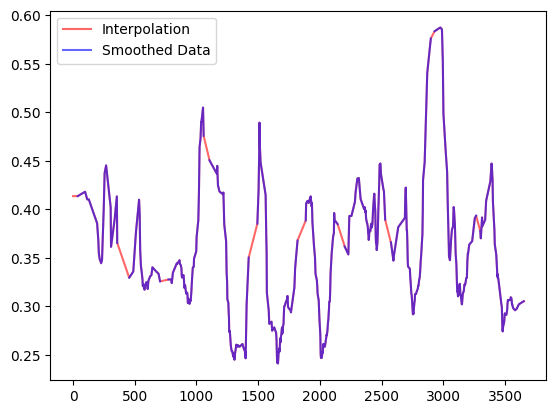

In [29]:
full_daily_0 = full_daily[full_daily['plot_id'] == 0].copy()

plt.plot(full_daily_0['ndvi_smooth_interp'], alpha = 0.6,color = 'red', label = 'Interpolation')

plt.plot(full_daily_0['ndvi_smooth'], alpha = 0.6, color = 'blue', label = 'Smoothed Data')
plt.legend()

In [30]:
full_daily

,index,ndvi,plot_id,ndvi_smooth,ndvi_residual,ndvi_residual_pct,month,week,year,ndvi_smooth_interp
0,2016-01-01,NaN,0.0,NaN,NaN,NaN,1,53,2016,0.413494
1,2016-01-02,NaN,0.0,NaN,NaN,NaN,1,53,2016,0.413494
2,2016-01-03,NaN,0.0,NaN,NaN,NaN,1,53,2016,0.413494
3,2016-01-04,NaN,0.0,NaN,NaN,NaN,1,1,2016,0.413494
4,2016-01-05,NaN,0.0,NaN,NaN,NaN,1,1,2016,0.413494
...,...,...,...,...,...,...,...,...,...,...
13143489,2025-12-27,0.414079,3597.0,0.413574,0.000505,0.001237,12,52,2025,0.413574
13143490,2025-12-28,0.413959,3597.0,0.413707,0.000253,0.000618,12,52,2025,0.413707
13143491,2025-12-29,0.413839,3597.0,0.413839,0.000000,0.000000,12,1,2025,0.413839
13143492,2025-12-30,NaN,3597.0,NaN,NaN,NaN,12,1,2025,0.413839


In [31]:
# Vectorized weekly stats — avoids building 1.8M dicts in a Python loop

# Pre-compute date ordinal once
full_daily["date_ord"] = full_daily["index"].map(pd.Timestamp.toordinal)
print('dated')
grp = full_daily.groupby(["plot_id", "year", "week"])
print('grouped')
# --- Standard stats (fully vectorized) ---
agg = grp["ndvi_smooth"].agg(
    ndvi_smooth_mean="mean",
    ndvi_smooth_std="std",
    ndvi_smooth_max="max",
    ndvi_smooth_min="min",
).reset_index()
print('agged')
# --- OLS slope via vectorized deviation formula ---d
# slope = sum((x - x_mean)(y - y_mean)) / sum((x - x_mean)^2)
full_daily["_x_mean"] = grp["date_ord"].transform("mean")
full_daily["_y_mean"] = grp["ndvi_smooth"].transform("mean")
full_daily["_xy_dev"] = (full_daily["date_ord"] - full_daily["_x_mean"]) *  (full_daily["ndvi_smooth"] - full_daily["_y_mean"])
full_daily["_x_dev2"] = (full_daily["date_ord"] - full_daily["_x_mean"]) ** 2

slope_df = grp[["_xy_dev", "_x_dev2"]].sum()
slope_df["ndvi_smooth_slope"] = slope_df["_xy_dev"] / slope_df["_x_dev2"].replace(0, np.nan)
slope_df = slope_df[["ndvi_smooth_slope"]].reset_index()
print('ols completed')
# Clean up temp columns
full_daily.drop(columns=["date_ord", "_x_mean", "_y_mean", "_xy_dev", "_x_dev2"], inplace=True)

# Merge stats and slope
weekly_stats_df = agg.merge(slope_df, on=["plot_id", "year", "week"])

print(weekly_stats_df.shape)
weekly_stats_df.head()


dated
grouped
agged
ols completed
(1881754, 8)


,plot_id,year,week,ndvi_smooth_mean,ndvi_smooth_std,ndvi_smooth_max,ndvi_smooth_min,ndvi_smooth_slope
0,0.0,2016,1,NaN,NaN,NaN,NaN,0.0
1,0.0,2016,2,NaN,NaN,NaN,NaN,0.0
2,0.0,2016,3,NaN,NaN,NaN,NaN,0.0
3,0.0,2016,4,NaN,NaN,NaN,NaN,0.0
4,0.0,2016,5,NaN,NaN,NaN,NaN,0.0


In [32]:
wsdf = weekly_stats_df.copy()
# wsdf = wsdf[wsdf['week'].isin([(i) for i in range(28, 45)])]

In [33]:
veg_agg = wsdf.copy() 

In [34]:
drop_cols = [col for col in veg_agg.columns if 'max' in col or 'min' in col]

In [35]:
veg_agg = veg_agg.drop(columns = drop_cols)

In [36]:
slope_cols = [c for c in veg_agg.columns if c.endswith('_slope')]
std_cols = [c for c in veg_agg.columns if c.endswith('_std')]

veg_agg[slope_cols] = veg_agg[slope_cols].fillna(0)
veg_agg[std_cols] = veg_agg[std_cols].fillna(0)


In [37]:
# Pivot so that each month becomes a set of columns
veg_agg_wide = veg_agg.pivot_table(
    index=['plot_id','year'],
    columns='week',
    values=[col for col in veg_agg.columns if col not in ['plot_id','year','week']]
).reset_index()

# Flatten multi-index columns
veg_agg_wide.columns = ['_'.join([str(c) for c in col if c != '']) for col in veg_agg_wide.columns]


In [38]:
ndvi_cols = [col for col in veg_agg_wide.columns if col.startswith('ndvi_smooth_mean')]

veg_agg_wide['ndvi_cov'] = veg_agg_wide[ndvi_cols].std(axis=1) / veg_agg_wide[ndvi_cols].mean(axis=1)
veg_agg_wide['ndvi_mean'] = veg_agg_wide[ndvi_cols].mean(axis = 1)
veg_agg_wide['ndvi_std'] = veg_agg_wide[ndvi_cols].std(axis = 1)

In [39]:
mu_min, mu_max = veg_agg_wide['ndvi_mean'].min(), veg_agg_wide['ndvi_mean'].max()
sigma_min, sigma_max = veg_agg_wide['ndvi_std'].min(), veg_agg_wide['ndvi_std'].max()
cov_min, cov_max = veg_agg_wide['ndvi_cov'].min(), veg_agg_wide['ndvi_cov'].max()

veg_agg_wide['ndvi_mean_norm'] = (veg_agg_wide['ndvi_mean'] - mu_min) / (mu_max - mu_min)

# reverse because higher sigma is worse
veg_agg_wide['ndvi_std_norm'] = (sigma_max - veg_agg_wide['ndvi_std']) / (sigma_max - sigma_min)

# reverse because higher cov is worse
veg_agg_wide['ndvi_cov_norm'] = (cov_max - veg_agg_wide['ndvi_cov']) / (cov_max - cov_min)

# Weighted geometric mean health score
w1, w2, w3 = 0.5, 0.25, 0.25

veg_agg_wide['health'] = (
    (veg_agg_wide['ndvi_mean_norm'] ** w1) *
    (veg_agg_wide['ndvi_std_norm']  ** w2) *
    (veg_agg_wide['ndvi_cov_norm']  ** w3)
) ** (1 / (w1 + w2 + w3))

veg_agg_wide[['plot_id', 'year', 'ndvi_mean', 'ndvi_std', 'ndvi_cov', 'health']].head()


,plot_id,year,ndvi_mean,ndvi_std,ndvi_cov,health
0,0.0,2016,0.399301,0.024442,0.061211,0.677199
1,0.0,2017,0.341236,0.022767,0.066718,0.598005
2,0.0,2018,0.355367,0.054636,0.153744,0.571971
3,0.0,2019,0.338190,0.080971,0.239423,0.505802
4,0.0,2020,0.325241,0.063091,0.193982,0.515006


In [40]:
df

,date,ndvi,plot_id,ndvi_smooth,ndvi_residual,ndvi_residual_pct,month,week,year
0,2016-02-08,0.413494,0.0,0.413494,0.000000,0.000000,2.000000,6,2016
1,2016-02-09,0.413664,0.0,0.413570,0.000094,0.000224,2.033333,6,2016
2,2016-02-10,0.413833,0.0,0.413646,0.000187,0.000447,2.066667,6,2016
3,2016-02-11,0.414003,0.0,0.413722,0.000281,0.000671,2.100000,6,2016
4,2016-02-12,0.414172,0.0,0.413798,0.000374,0.000895,2.133333,6,2016
...,...,...,...,...,...,...,...,...,...
11175383,2025-12-25,0.414319,3597.0,0.413308,0.001010,0.002473,11.900000,52,2025
11175384,2025-12-26,0.414199,3597.0,0.413441,0.000758,0.001855,11.925000,52,2025
11175385,2025-12-27,0.414079,3597.0,0.413574,0.000505,0.001237,11.950000,52,2025
11175386,2025-12-28,0.413959,3597.0,0.413707,0.000253,0.000618,11.975000,52,2025


In [41]:
veg_agg_wide.to_pickle('../data/ndvi/plots/final_df.pkl')